# Evaluate held-out test performance results for CardioAkita against Original Akita predictions

In [1]:
import os
import h5py
import numpy as np
import tensorflow as tf
import pysam
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


2026-04-10 15:37:17.157060: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-04-10 15:37:17.157081: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [2]:
# ventricular prediction against ventricular measured maps
v_mse = np.load("/.../performance_scores/ventricular_test_mse.npy")
v_pearsonr = np.load("/.../performance_scores/ventricular_test_pearsonr.npy")

# atrial prediction against atrial measured maps
a_mse = np.load("/.../performance_scores/atrial_test_mse.npy")
a_pearsonr = np.load("/.../performance_scores/atrial_test_pearsonr.npy")

# H1hESC prediction against ventricular d0 (iPSC) measured maps
H1hESC_mse_vd0_targets = np.load("/.../performance_scores/H1hESC_test_mse_vd0_targets.npy")
H1hESC_pearsonR_vd0_targets = np.load("/.../performance_scores/H1hESC_test_pearsonr_vd0_targets.npy")

# H1hESC prediction against atrial d0 (iPSC) measured maps
H1hESC_mse_ad0_targets = np.load("/.../performance_scores/H1hESC_test_mse_ad0_targets.npy")
H1hESC_pearsonR_ad0_targets = np.load("/.../performance_scores/H1hESC_test_pearsonr_ad0_targets.npy")


print("v_mse.shape", v_mse.shape)
print("v_pearsonr.shape", v_pearsonr.shape)

print("H1hESC_mse.shape", H1hESC_mse_vd0_targets.shape)
print("H1hESC_pearsonR.shape", H1hESC_pearsonR_vd0_targets.shape)

print("a_mse.shape", a_mse.shape)
print("a_pearsonr.shape", a_pearsonr.shape)

v_mse.shape (413, 6)
v_pearsonr.shape (413, 6)
H1hESC_mse.shape (413, 1)
H1hESC_pearsonR.shape (413, 1)
a_mse.shape (413, 7)
a_pearsonr.shape (413, 7)


# Plot held-out test performance (MSE and 1-PearsonR) for: 
## 1. CardioAkita ventricular model prediction against measured maps at iPSC time point of cardiomyocyte differentiation 
## 2. Original Akita model prediction at H1hESC against measured maps at iPSC time point of cardiomyocyte differentiation

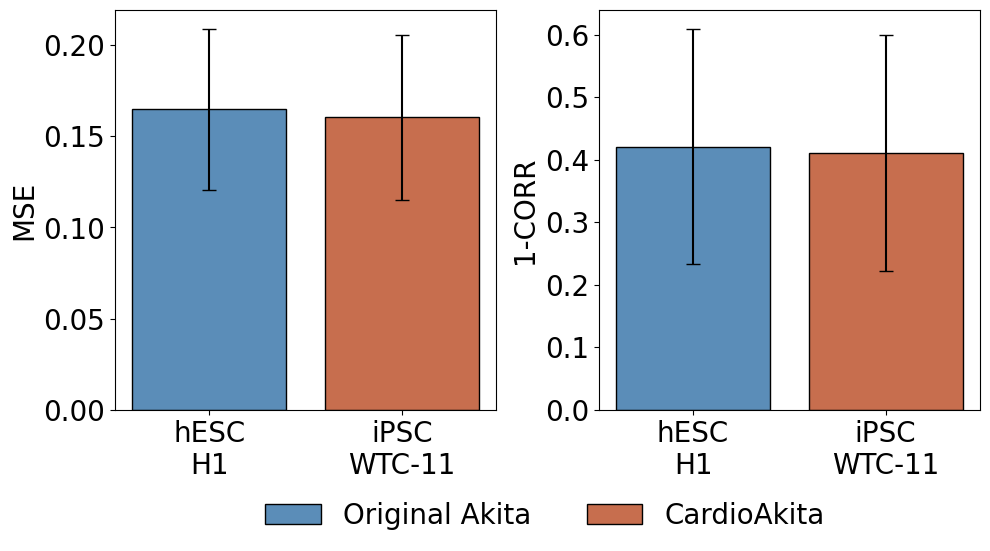

In [3]:
# Data arrays
mse_data = [H1hESC_mse_vd0_targets, v_mse[:, 0]]
pearsonr_data = [H1hESC_pearsonR_vd0_targets, v_pearsonr[:, 0]]
legend_labels = ['Original Akita', 'CardioAkita']


groups = ['hESC\nH1', 'iPSC\nWTC-11']
colors = [
    "#5B8DB8", 
    "#C76E4E", 
]

x = np.arange(len(groups))

means = [np.mean(d) for d in mse_data]
stds  = [np.std(d) for d in mse_data]

pearsonr_data_1_minus = [1 - d for d in pearsonr_data]

means_1 = [np.mean(d) for d in pearsonr_data_1_minus]
stds_1  = [np.std(d) for d in pearsonr_data_1_minus]


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].bar(
    x,
    means,
    yerr=stds,
    capsize=5,
    color=colors,
    edgecolor='black'
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(groups, fontsize=20)
axes[0].tick_params(axis='y', labelsize=20)
axes[0].set_ylabel('MSE', fontsize=20)
#######################################################
axes[1].bar(
    x,
    means_1,
    yerr=stds_1,
    capsize=5,
    color=colors,
    edgecolor='black'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, fontsize=20)
axes[1].tick_params(axis='y', labelsize=20)
axes[1].set_ylabel('1-CORR', fontsize=20)


# ---------- Legend ----------
legend_handles = [
    Patch(facecolor=c, edgecolor='black', label=l)
    for c, l in zip(colors, legend_labels)
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=2,
    frameon=False,
    fontsize=20,
    bbox_to_anchor=(0.55, -0.12)
)

plt.tight_layout()
plt.show()


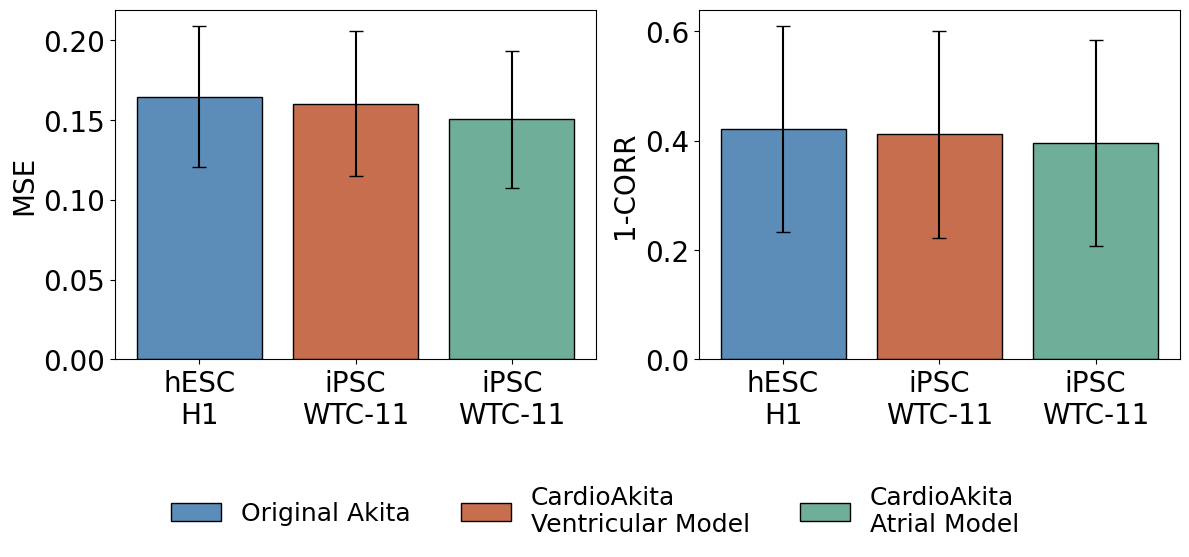

In [4]:
mse_data = [(H1hESC_mse_vd0_targets), (v_mse[:, 0]), (a_mse[:, 0])]

pearsonr_data = [H1hESC_pearsonR_vd0_targets, v_pearsonr[:, 0], a_pearsonr[:, 0]]

groups = ['hESC\nH1', 'iPSC\nWTC-11', 'iPSC\nWTC-11']
legend_labels = ['Original Akita', 'CardioAkita\nVentricular Model', 'CardioAkita\nAtrial Model']

colors = [
    "#5B8DB8",  # muted blue
    "#C76E4E",  # muted vermillion
    "#6FAF9A",  # muted green
]

x = np.arange(len(groups))

means = [np.mean(d) for d in mse_data]
stds  = [np.std(d) for d in mse_data]

pearsonr_data_1_minus = [1 - d for d in pearsonr_data]
means_1 = [np.mean(d) for d in pearsonr_data_1_minus]
stds_1  = [np.std(d) for d in pearsonr_data_1_minus]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- MSE ---
axes[0].bar(
    x, means, yerr=stds, capsize=5,
    color=colors, edgecolor='black'
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(groups, fontsize=20)
axes[0].tick_params(axis='y', labelsize=20)
# axes[0].set_ylabel('log10(MSE)', fontsize=20)
axes[0].set_ylabel('MSE', fontsize=20)

# --- PearsonR ---
axes[1].bar(
    x, means_1, yerr=stds_1, capsize=5,
    color=colors, edgecolor='black'
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, fontsize=20)
axes[1].tick_params(axis='y', labelsize=20)
# axes[1].set_ylabel('PearsonR', fontsize=20)
axes[1].set_ylabel('1-CORR', fontsize=20)


# ---------- Legend ----------
legend_handles = [
    Patch(facecolor=c, edgecolor='black', label=l)
    for c, l in zip(colors, legend_labels)
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=3,
    frameon=False,
    fontsize=18,
    bbox_to_anchor=(0.5, -0.13)
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

# Plotting predictions per genomic window across held-out test regions 

<Figure size 600x600 with 0 Axes>

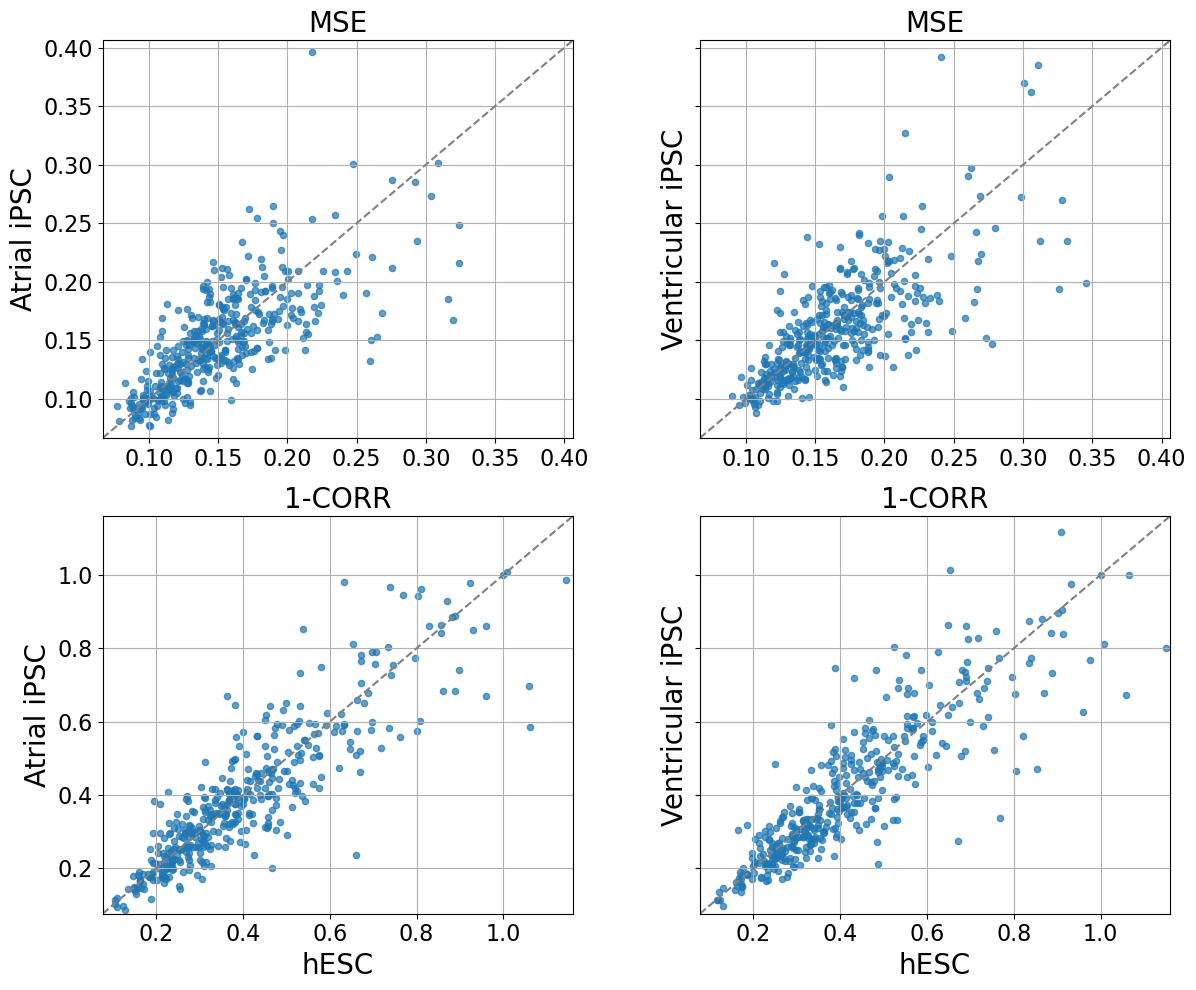

In [5]:
plt.figure(figsize=(6, 6))

max_per_row = np.max(v_pearsonr, axis=1) 

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex="row", sharey="row") 

# ==========================
# GLOBAL LIMITS PER ROW
# ==========================

# --- MSE limits (top row) ---
mse_min = min(
    H1hESC_mse_vd0_targets.min(),
    H1hESC_mse_ad0_targets.min(),
    a_mse[:, 0].min(),
    v_mse[:, 0].min()
) - 0.01

mse_max = max(
    H1hESC_mse_vd0_targets.max(),
    H1hESC_mse_ad0_targets.max(),
    a_mse[:, 0].max(),
    v_mse[:, 0].max()
) +0.01

# --- PearsonR limits (bottom row) ---
pearson_min = min(
    (1-H1hESC_pearsonR_vd0_targets).min(),
    (1-H1hESC_pearsonR_ad0_targets).min(),
    (1-a_pearsonr[:, 0]).min(),
    (1-v_pearsonr[:, 0]).min()
) -0.01

pearson_max = max(
    (1-H1hESC_pearsonR_vd0_targets).max(),
    (1-H1hESC_pearsonR_ad0_targets).max(),
    (1-a_pearsonr[:, 0]).max(),
    (1-v_pearsonr[:, 0]).max()
) + 0.01

# ==========================
# TOP ROW — MSE
# ==========================

# Atrial MSE
axes[0, 0].scatter(H1hESC_mse_ad0_targets, a_mse[:, 0], alpha=0.7, s=20,color='#1f77b4')
axes[0, 0].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 0].set_xlim(mse_min, mse_max)
axes[0, 0].set_ylim(mse_min, mse_max)
axes[0, 0].set_title("MSE",fontsize=20)
axes[0, 0].set_ylabel("Atrial iPSC",fontsize=20)
axes[0, 0].tick_params(axis='both', which='major', labelsize=16)
axes[0, 0].grid(True)

# Ventricular MSE
axes[0, 1].scatter(H1hESC_mse_vd0_targets, v_mse[:, 0], alpha=0.7, s=20,color='#1f77b4')
axes[0, 1].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 1].set_xlim(mse_min, mse_max)
axes[0, 1].set_ylim(mse_min, mse_max)
# axes[0, 1].set_ylabel("Ventricular iPSC",fontsize=20)
axes[0, 1].set_ylabel("Ventricular iPSC",fontsize=20)
axes[0, 1].set_title("MSE",fontsize=20)
axes[0, 1].tick_params(axis='both', which='major', labelsize=16)
axes[0, 1].grid(True)

# ==========================
# BOTTOM ROW — PEARSON R
# ==========================

# Atrial PearsonR
axes[1, 0].scatter(1-H1hESC_pearsonR_ad0_targets, 1-a_pearsonr[:, 0], alpha=0.7, s=20,color='#1f77b4')
axes[1, 0].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 0].set_xlim(pearson_min, pearson_max)
axes[1, 0].set_ylim(pearson_min, pearson_max)
axes[1, 0].set_title("1-CORR",fontsize=20)
axes[1, 0].set_xlabel("",fontsize=20)
axes[1, 0].set_ylabel("Atrial iPSC",fontsize=20)
axes[1, 0].set_xlabel("hESC",fontsize=20)
axes[1, 0].tick_params(axis='both', which='major', labelsize=16)
axes[1, 0].grid(True)

# Ventricular PearsonR
axes[1, 1].scatter(1-H1hESC_pearsonR_vd0_targets, 1-v_pearsonr[:, 0], alpha=0.7, s=20,color='#1f77b4')
axes[1, 1].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 1].set_xlim(pearson_min, pearson_max)
axes[1, 1].set_ylim(pearson_min, pearson_max)
axes[1, 1].set_title("1-CORR",fontsize=20)
axes[1, 1].set_xlabel("",fontsize=20)
axes[1, 1].set_ylabel("Ventricular iPSC",fontsize=20)
axes[1, 1].set_xlabel("hESC",fontsize=20)
axes[1, 1].tick_params(axis='both', which='major', labelsize=16)
axes[1, 1].grid(True)
plt.tight_layout()

fig.subplots_adjust(wspace=0.27)   
plt.show()


# CardioAkita and Original Akita predictions against atrial day 45 (D45) and ventricular day 23 (D23) measured maps

H1hESC_pearsonR_ad45 shape (413, 1)
H1hESC_pearsonR_vd23 shape (413, 1)
H1hESC_MSE_ad45 shape (413, 1)
H1hESC_MSE_vd23 shape (413, 1)
HFF_pearsonR_ad45 shape (413, 1)
HFF_pearsonR_vd23 shape (413, 1)
HFF_MSE_ad45 shape (413, 1)
HFF_MSE_vd23 shape (413, 1)


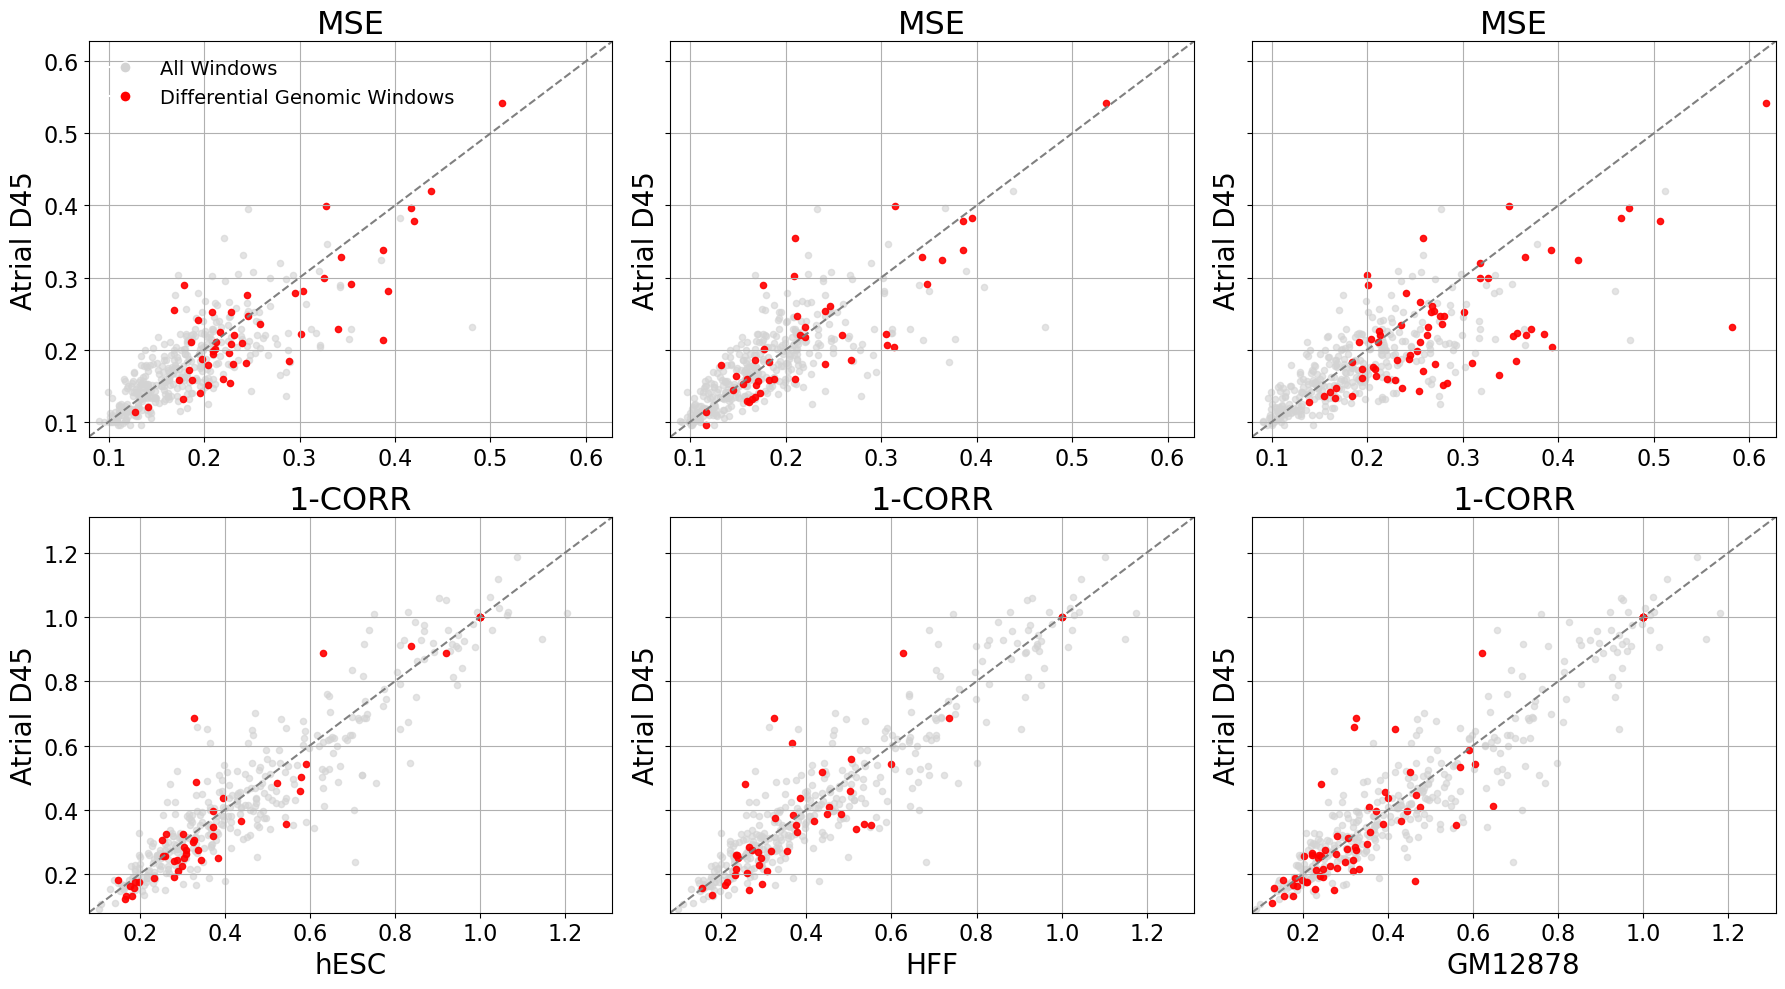

In [6]:
# Indicies of held-out test genomic regions where measured H1hESC and Ventricular D23 maps have a MSE greater than 0.28  
v_filtered_index_list_H1hESC = np.array([8, 13, 21, 25, 45, 52, 59, 80, 82, 84, 99, 106, 118, 127, 130, 136, 138, 142, 146, 150, 151, 174, 202, 213, 214, 221, 222, 224, 229, 234, 240, 251, 257, 258, 259, 264, 271, 272, 278, 286, 293, 314, 319, 320, 321, 326, 360, 389])
# Indicies of held-out test genomic regions where measured H1hESC and Atrial D45 maps have a MSE greater than 0.245
a_filtered_index_list_H1hESC = np.array([8, 13, 15, 21, 25, 43, 59, 82, 84, 102, 104, 118, 126, 130, 136, 138, 150, 151, 179, 200, 202, 214, 221, 224, 229, 251, 255, 258, 259, 265, 271, 272, 278, 286, 293, 319, 320, 326, 340, 342, 349, 360, 364, 374, 379, 391, 396, 405])

# # ==========================
# # LOAD DATA
# # ==========================

# CardioAkita Ventricular D23 and Atrial D45 measured maps compared with H1hESC predictions from Original Akita 
H1hESC_pearsonR_ad45 = np.load("/.../H1hESC_prediction_against_AD45_targets_pearsonR.npy")
H1hESC_pearsonR_vd23 = np.load("/.../performance_scores/H1hESC_prediction_against_VD23_targets_pearsonR.npy")
H1hESC_MSE_ad45 = np.load("/.../performance_scores/H1hESC_prediction_against_AD45_targets_mse.npy")
H1hESC_MSE_vd23 = np.load("/.../performance_scores/H1hESC_prediction_against_VD23_targets_mse.npy")
print("H1hESC_pearsonR_ad45 shape", H1hESC_pearsonR_ad45.shape)
print("H1hESC_pearsonR_vd23 shape", H1hESC_pearsonR_vd23.shape)
print("H1hESC_MSE_ad45 shape", H1hESC_MSE_ad45.shape)
print("H1hESC_MSE_vd23 shape", H1hESC_MSE_vd23.shape)

# Indicies of held-out test genomic regions where measured HFF and Ventricular D23 maps have a MSE greater than 0.285
v_filtered_index_list_HFF = np.array([13, 22, 24, 33, 35, 39, 48, 52, 59, 70, 73, 82, 84, 88, 90, 92, 97, 99, 105, 110, 111, 114, 119, 143, 150, 152, 170, 177, 187, 188, 190, 192, 206, 213, 231, 234, 255, 259, 260, 264, 268, 271, 272, 276, 278, 284, 295, 298, 314, 321, 346, 352, 360, 361, 366, 373, 383, 386, 407])

# Indicies of held-out test genomic regions where measured H1hESC and Atrial D45 maps have a MSE greater than 0.3
a_filtered_index_list_HFF = np.array([13, 22, 24, 31, 35, 52, 59, 82, 84, 97, 105, 110, 111, 114, 119, 140, 143, 150, 152, 168, 177, 187, 190, 206, 213, 259, 264, 268, 270, 271, 272, 276, 293, 298, 319, 328, 352, 366, 373, 375, 383, 384, 386])

# CardioAkita Ventricular D23 and Atrial D45 measured maps compared with HFF predictions from Original Akita 
HFF_pearsonR_ad45 = np.load("/.../performance_scores/HFF_prediction_against_AD45_targets_pearsonR.npy")
HFF_pearsonR_vd23 = np.load("/.../performance_scores/HFF_prediction_against_VD23_targets_pearsonR.npy")
HFF_MSE_ad45 = np.load("/.../performance_scores/HFF_prediction_against_AD45_targets_mse.npy") 
HFF_MSE_vd23 = np.load("/.../performance_scores/HFF_prediction_against_VD23_targets_mse.npy")
print("HFF_pearsonR_ad45 shape", H1hESC_pearsonR_ad45.shape)
print("HFF_pearsonR_vd23 shape", H1hESC_pearsonR_vd23.shape)
print("HFF_MSE_ad45 shape", H1hESC_MSE_ad45.shape)
print("HFF_MSE_vd23 shape", H1hESC_MSE_vd23.shape)

# CardioAkita Ventricular D23 and Atrial D45 measured maps compared with GM1278 predictions from Original Akita 
GM12878_MSE_ad45 = np.load("/.../performance_scores/GM12878_prediction_against_AD45_targets_mse.npy")
GM12878_pearsonR_ad45 = np.load("/.../performance_scores/GM12878_prediction_against_AD45_targets_pearsonR.npy")
GM12878_MSE_vd23 = np.load("/.../performance_scores/GM12878_prediction_against_VD23_targets_mse.npy")
GM12878_pearsonR_vd23 = np.load("/.../performance_scores/GM12878_prediction_against_VD23_targets_pearsonR.npy")

# Indicies of held-out test genomic regions where measured GM12878 and Atrial D45 maps have a MSE greater than 0.3
a_filtered_index_list_GM12878 = np.array([8, 13, 15, 18, 21, 25, 26, 31, 39, 59, 61, 76, 82, 84, 105, 107, 111, 129, 146, 150, 165, 168, 175, 187, 190, 198, 206, 211, 229, 233, 241, 247, 251, 256, 258, 259, 264, 265, 272, 274, 276, 278, 281, 293, 300, 306, 314, 315, 318, 319, 321, 327, 328, 334, 341, 349, 352, 354, 357, 360, 363, 369, 387, 389, 396, 407])
# Indicies of held-out test genomic regions where measured GM12878 and Ventricular D23 maps have a MSE greater than 0.3
v_filtered_index_list_GM12878 = np.array([8, 13, 18, 21, 25, 26, 30, 33, 39, 45, 48, 56, 59, 61, 63, 68, 70, 76, 84, 88, 97, 99, 105, 107, 111, 127, 129, 138, 146, 150, 151, 162, 165, 168, 174, 175, 179, 187, 190, 198, 206, 211, 213, 223, 229, 233, 247, 248, 255, 256, 257, 258, 259, 264, 265, 268, 271, 272, 274, 276, 277, 278, 281, 289, 300, 306, 307, 313, 314, 315, 318, 319, 321, 327, 336, 349, 352, 353, 357, 360, 363, 369, 389, 396, 400, 407, 411])


# ==========================
# BUILD MASK
# ==========================
# H1hESC Mask 
v_mask_H1hESC = np.zeros(len(H1hESC_MSE_ad45), dtype=bool)
v_mask_H1hESC[v_filtered_index_list_H1hESC] = True
a_mask_H1hESC = np.zeros(len(H1hESC_MSE_ad45), dtype=bool)
a_mask_H1hESC[a_filtered_index_list_H1hESC] = True
# HFF Mask
v_mask_HFF = np.zeros(len(HFF_MSE_ad45), dtype=bool)
v_mask_HFF[v_filtered_index_list_HFF] = True
a_mask_HFF = np.zeros(len(HFF_MSE_ad45), dtype=bool)
a_mask_HFF[a_filtered_index_list_HFF] = True
# GM12878 Mask 
v_mask_GM12878 = np.zeros(len(GM12878_MSE_vd23), dtype=bool)
v_mask_GM12878[v_filtered_index_list_GM12878] = True
a_mask_GM12878 = np.zeros(len(GM12878_MSE_ad45), dtype=bool)
a_mask_GM12878[a_filtered_index_list_GM12878] = True


fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    sharex="row",
    sharey="row"
)


# ==========================
# GLOBAL LIMITS PER ROW
# ==========================


# --- MSE limits (top row) ---
mse_min = min(
    H1hESC_MSE_ad45[:].min(),
    HFF_MSE_ad45[:].min(),
    GM12878_MSE_ad45[:].min(),
    a_mse[:, 6].min(),
    v_mse[:, 5].min()
) - 0.01

mse_max = max(
    H1hESC_MSE_ad45[:].max(),
    HFF_MSE_ad45[:].max(),
    GM12878_MSE_ad45[:].max(),
    a_mse[:, 6].max(),
    v_mse[:, 5].max()
) + 0.01

pearson_min = min(
    (1-HFF_pearsonR_ad45[:]).min(),
    (1-H1hESC_pearsonR_ad45[:]).min(),
    (1-GM12878_pearsonR_ad45[:]).min(),
    (1-a_pearsonr[:, 6]).min(),
    (1-v_pearsonr[:, 5]).min()
) - 0.01

pearson_max = max(
    (1-HFF_pearsonR_ad45[:]).max(),
    (1-H1hESC_pearsonR_ad45[:]).max(),
    (1-GM12878_pearsonR_ad45[:]).max(),
    (1-a_pearsonr[:, 6]).max(),
    (1-v_pearsonr[:, 5]).max()
) + 0.01


axes[0, 0].scatter(
    H1hESC_MSE_ad45[~a_mask_H1hESC], a_mse[~a_mask_H1hESC, 6],
    color="lightgray", alpha=0.6, s=20
)
axes[0, 0].scatter(
    H1hESC_MSE_ad45[a_mask_H1hESC], a_mse[a_mask_H1hESC, 6],
    color="red", alpha=0.9, s=20
)
axes[0, 0].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 0].set_xlim(mse_min, mse_max)
axes[0, 0].set_ylim(mse_min, mse_max)
axes[0, 0].set_title("MSE",fontsize=23)
axes[0, 0].set_ylabel("Atrial D45",fontsize=20)
axes[0, 0].tick_params(axis='both', which='major', labelsize=16)
axes[0, 0].grid(True)

axes[0, 1].scatter(
    HFF_MSE_ad45[~a_mask_HFF], a_mse[~a_mask_HFF, 6],
    color="lightgray", alpha=0.6, s=20
)
axes[0, 1].scatter(
    HFF_MSE_ad45[a_mask_HFF], a_mse[a_mask_HFF, 6],
    color="red", alpha=0.9, s=20
)
axes[0, 1].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 1].set_xlim(mse_min, mse_max)
axes[0, 1].set_ylim(mse_min, mse_max)
axes[0, 1].set_ylabel("Atrial D45",fontsize=20)
axes[0, 1].set_title("MSE",fontsize=23)
axes[0, 1].tick_params(axis='both', which='major', labelsize=16)
axes[0, 1].grid(True)

axes[0, 2].scatter(
    GM12878_MSE_ad45[~a_mask_GM12878], a_mse[~a_mask_GM12878, 6],
    color="lightgray", alpha=0.6, s=20
)
axes[0, 2].scatter(
    GM12878_MSE_ad45[a_mask_GM12878], a_mse[a_mask_GM12878, 6],
    color="red", alpha=0.9, s=20
)
axes[0, 2].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 2].set_xlim(mse_min, mse_max)
axes[0, 2].set_ylim(mse_min, mse_max)
axes[0, 2].set_ylabel("Atrial D45",fontsize=20)
axes[0, 2].set_title("MSE",fontsize=23)
axes[0, 2].tick_params(axis='both', which='major', labelsize=16)
axes[0, 2].grid(True)

# ==========================
# BOTTOM ROW — PEARSON R
# ==========================

axes[1, 0].scatter(
    1-H1hESC_pearsonR_ad45[~a_mask_H1hESC], 1-a_pearsonr[~a_mask_H1hESC, 6],
    color="lightgray", alpha=0.6, s=20
)
axes[1, 0].scatter(
    1-H1hESC_pearsonR_ad45[a_mask_H1hESC], 1-a_pearsonr[a_mask_H1hESC, 6],
    color="red", alpha=0.9, s=20
)
axes[1, 0].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 0].set_xlim(pearson_min, pearson_max)
axes[1, 0].set_ylim(pearson_min, pearson_max)
axes[1, 0].set_title("1-CORR",fontsize=23)
axes[1, 0].set_xlabel("",fontsize=20)
axes[1, 0].set_ylabel("Atrial D45",fontsize=20)
axes[1, 0].set_xlabel("hESC",fontsize=20)
axes[1, 0].tick_params(axis='both', which='major', labelsize=16)
axes[1, 0].grid(True)

axes[1, 1].scatter(
    1-HFF_pearsonR_ad45[~a_mask_HFF], 1-a_pearsonr[~a_mask_HFF, 6],
    color="lightgray", alpha=0.6, s=20)
axes[1, 1].scatter(
    1-HFF_pearsonR_ad45[a_mask_HFF], 1-a_pearsonr[a_mask_HFF, 6],
    color="red", alpha=0.9, s=20)
axes[1, 1].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 1].set_xlim(pearson_min, pearson_max)
axes[1, 1].set_ylim(pearson_min, pearson_max)
axes[1, 1].set_title("1-CORR",fontsize=23)
axes[1, 1].set_xlabel("",fontsize=20)
axes[1, 1].set_ylabel("Atrial D45",fontsize=20)
axes[1, 1].set_xlabel("HFF",fontsize=20)
axes[1, 1].tick_params(axis='both', which='major', labelsize=16)
axes[1, 1].grid(True)

axes[1, 2].scatter(
    1-GM12878_pearsonR_ad45[~a_mask_GM12878], 1-a_pearsonr[~a_mask_GM12878, 6],
    color="lightgray", alpha=0.6, s=20)
axes[1, 2].scatter(
    1-GM12878_pearsonR_ad45[a_mask_GM12878], 1-a_pearsonr[a_mask_GM12878, 6],
    color="red", alpha=0.9, s=20)
axes[1, 2].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 2].set_xlim(pearson_min, pearson_max)
axes[1, 2].set_ylim(pearson_min, pearson_max)
axes[1, 2].set_title("1-CORR",fontsize=23)
axes[1, 2].set_xlabel("",fontsize=20)
axes[1, 2].set_ylabel("Atrial D45",fontsize=20)
axes[1, 2].set_xlabel("GM12878",fontsize=20)
axes[1, 2].tick_params(axis='both', which='major', labelsize=16)
axes[1, 2].grid(True)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='All Windows', markerfacecolor='lightgray', markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label='Differential Genomic Windows', markerfacecolor='red', markersize=8),
]

axes[0,0].legend(handles=legend_elements, frameon=False, fontsize=14)

plt.tight_layout()
plt.show()


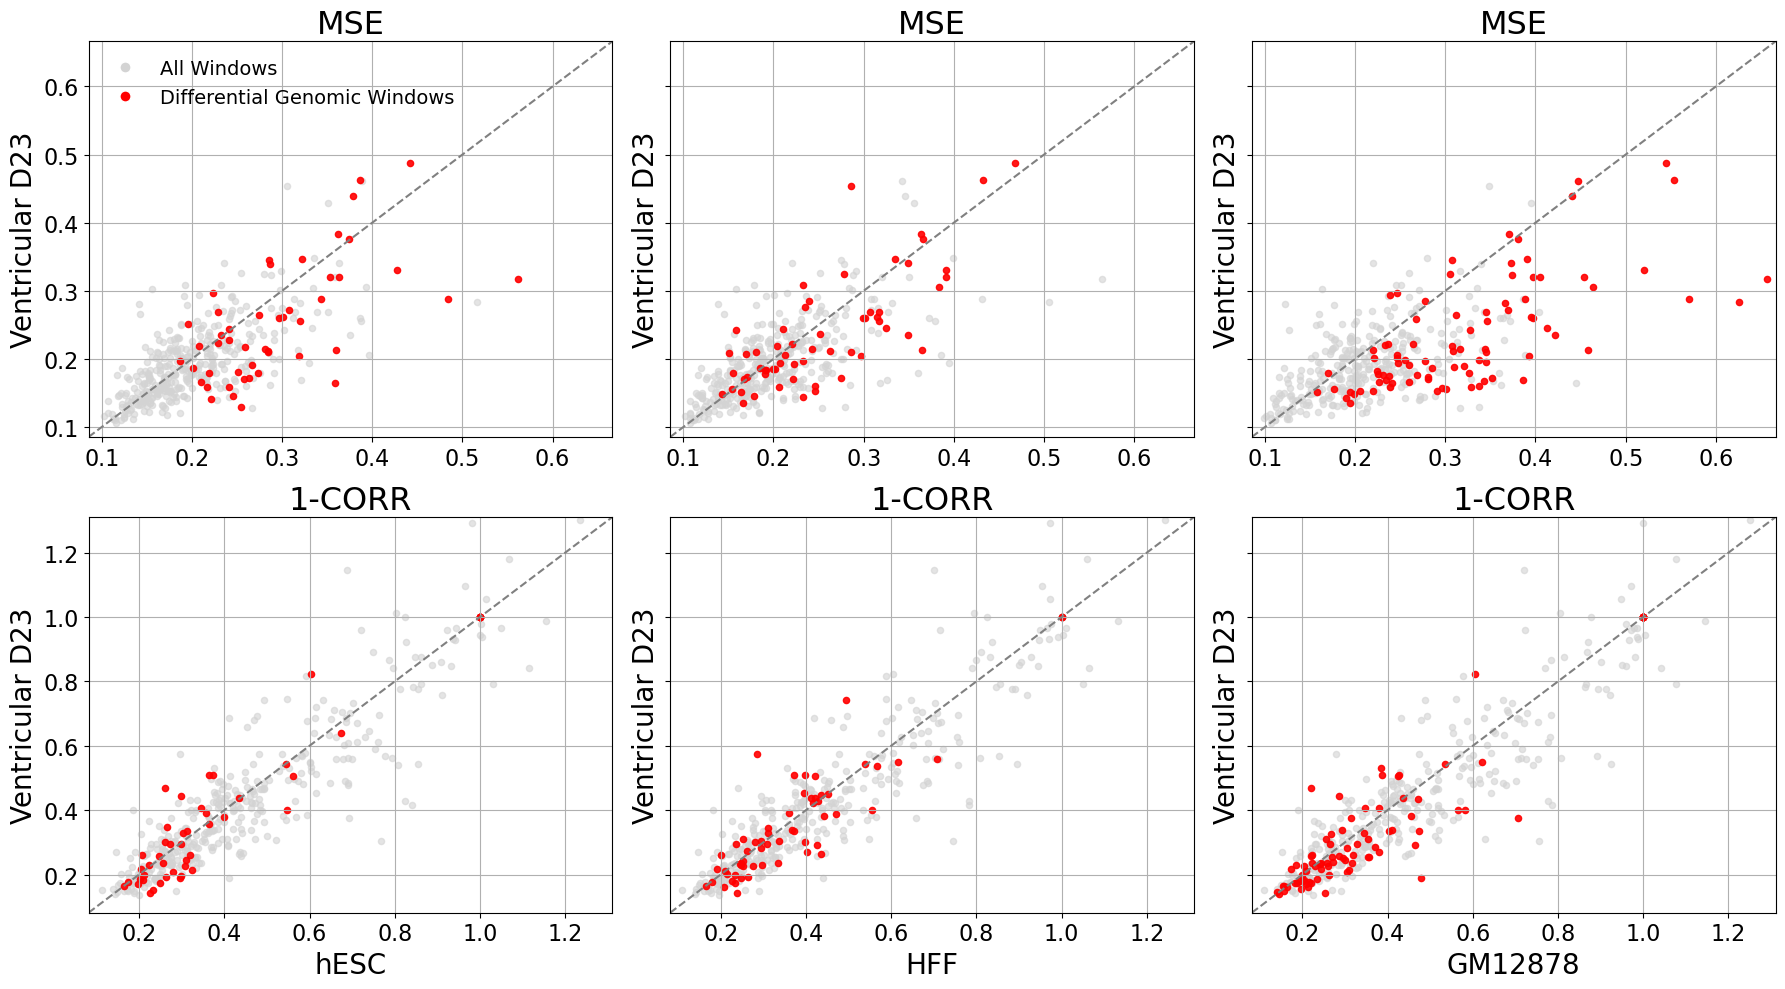

In [7]:
# H1hESC Mask 
v_mask_H1hESC = np.zeros(len(H1hESC_MSE_ad45), dtype=bool)
v_mask_H1hESC[v_filtered_index_list_H1hESC] = True
a_mask_H1hESC = np.zeros(len(H1hESC_MSE_ad45), dtype=bool)
a_mask_H1hESC[a_filtered_index_list_H1hESC] = True
# HFF Mask
v_mask_HFF = np.zeros(len(HFF_MSE_ad45), dtype=bool)
v_mask_HFF[v_filtered_index_list_HFF] = True
a_mask_HFF = np.zeros(len(HFF_MSE_ad45), dtype=bool)
a_mask_HFF[a_filtered_index_list_HFF] = True
# GM12878 Mask 
v_mask_GM12878 = np.zeros(len(GM12878_MSE_vd23), dtype=bool)
v_mask_GM12878[v_filtered_index_list_GM12878] = True
a_mask_GM12878 = np.zeros(len(GM12878_MSE_ad45), dtype=bool)
a_mask_GM12878[a_filtered_index_list_GM12878] = True


fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    sharex="row",
    sharey="row"
)


# ==========================
# GLOBAL LIMITS PER ROW
# ==========================


# --- MSE limits (top row) ---
mse_min = min(
    H1hESC_MSE_vd23[:].min(),
    HFF_MSE_vd23[:].min(),
    GM12878_MSE_vd23[:].min(),
    a_mse[:, 6].min(),
    v_mse[:, 5].min()
) - 0.01

mse_max = max(
    H1hESC_MSE_vd23[:].max(),
    HFF_MSE_vd23[:].max(),
    GM12878_MSE_vd23[:].max(),
    a_mse[:, 6].max(),
    v_mse[:, 5].max()
) + 0.01

pearson_min = min(
    (1-HFF_pearsonR_vd23[:]).min(),
    (1-H1hESC_pearsonR_vd23[:]).min(),
    (1-GM12878_pearsonR_vd23[:]).min(),
    (1-a_pearsonr[:, 6]).min(),
    (1-v_pearsonr[:, 5]).min()
) - 0.01

pearson_max = max(
    (1-HFF_pearsonR_vd23[:]).max(),
    (1-H1hESC_pearsonR_vd23[:]).max(),
    (1-GM12878_pearsonR_vd23[:]).max(),
    (1-a_pearsonr[:, 6]).max(),
    (1-v_pearsonr[:, 5]).max()
) + 0.01


axes[0, 0].scatter(
    H1hESC_MSE_vd23[~v_mask_H1hESC], v_mse[~v_mask_H1hESC, 5],
    color="lightgray", alpha=0.6, s=20
)
axes[0, 0].scatter(
    H1hESC_MSE_vd23[v_mask_H1hESC], v_mse[v_mask_H1hESC, 5],
    color="red", alpha=0.9, s=20
)
axes[0, 0].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 0].set_xlim(mse_min, mse_max)
axes[0, 0].set_ylim(mse_min, mse_max)
axes[0, 0].set_title("MSE",fontsize=23)
axes[0, 0].set_ylabel("Ventricular D23",fontsize=20)
axes[0, 0].tick_params(axis='both', which='major', labelsize=16)
axes[0, 0].grid(True)

axes[0, 1].scatter(
    HFF_MSE_vd23[~v_mask_HFF], v_mse[~v_mask_HFF, 5],
    color="lightgray", alpha=0.6, s=20
)
axes[0, 1].scatter(
    HFF_MSE_vd23[v_mask_HFF], v_mse[v_mask_HFF, 5],
    color="red", alpha=0.9, s=20
)
axes[0, 1].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 1].set_xlim(mse_min, mse_max)
axes[0, 1].set_ylim(mse_min, mse_max)
axes[0, 1].set_ylabel("Ventricular D23",fontsize=20)
axes[0, 1].set_title("MSE",fontsize=23)
axes[0, 1].tick_params(axis='both', which='major', labelsize=16)
axes[0, 1].grid(True)

axes[0, 2].scatter(
    GM12878_MSE_vd23[~v_mask_GM12878], v_mse[~v_mask_GM12878, 5],
    color="lightgray", alpha=0.6, s=20
)
axes[0, 2].scatter(
    GM12878_MSE_vd23[v_mask_GM12878], v_mse[v_mask_GM12878, 5],
    color="red", alpha=0.9, s=20
)
axes[0, 2].plot([mse_min, mse_max], [mse_min, mse_max], '--', color='grey')
axes[0, 2].set_xlim(mse_min, mse_max)
axes[0, 2].set_ylim(mse_min, mse_max)
axes[0, 2].set_ylabel("Ventricular D23",fontsize=20)
axes[0, 2].set_title("MSE",fontsize=23)
axes[0, 2].tick_params(axis='both', which='major', labelsize=16)
axes[0, 2].grid(True)

# ==========================
# BOTTOM ROW — PEARSON R
# ==========================

axes[1, 0].scatter(
    1-H1hESC_pearsonR_vd23[~v_mask_H1hESC], 1-v_pearsonr[~v_mask_H1hESC, 5],
    color="lightgray", alpha=0.6, s=20
)
axes[1, 0].scatter(
    1-H1hESC_pearsonR_vd23[v_mask_H1hESC], 1-v_pearsonr[v_mask_H1hESC, 5],
    color="red", alpha=0.9, s=20
)
axes[1, 0].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 0].set_xlim(pearson_min, pearson_max)
axes[1, 0].set_ylim(pearson_min, pearson_max)
axes[1, 0].set_title("1-CORR",fontsize=23)
axes[1, 0].set_xlabel("",fontsize=20)
axes[1, 0].set_ylabel("Ventricular D23",fontsize=20)
axes[1, 0].set_xlabel("hESC",fontsize=20)
# axes[1, 0].set_ylabel("Atrial iPSC",fontsize=20)
axes[1, 0].tick_params(axis='both', which='major', labelsize=16)
axes[1, 0].grid(True)

# Ventricular PearsonR
axes[1, 1].scatter(
    1-HFF_pearsonR_vd23[~v_mask_HFF], 1-v_pearsonr[~v_mask_HFF, 5],
    color="lightgray", alpha=0.6, s=20)
axes[1, 1].scatter(
    1-HFF_pearsonR_vd23[v_mask_HFF], 1-v_pearsonr[v_mask_HFF, 5],
    color="red", alpha=0.9, s=20)
axes[1, 1].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 1].set_xlim(pearson_min, pearson_max)
axes[1, 1].set_ylim(pearson_min, pearson_max)
axes[1, 1].set_title("1-CORR",fontsize=23)
axes[1, 1].set_xlabel("",fontsize=20)
axes[1, 1].set_ylabel("Ventricular D23",fontsize=20)
axes[1, 1].set_xlabel("HFF",fontsize=20)
axes[1, 1].tick_params(axis='both', which='major', labelsize=16)
axes[1, 1].grid(True)

axes[1, 2].scatter(
    1-GM12878_pearsonR_vd23[~v_mask_GM12878], 1-v_pearsonr[~v_mask_GM12878, 5],
    color="lightgray", alpha=0.6, s=20)
axes[1, 2].scatter(
    1-GM12878_pearsonR_vd23[v_mask_GM12878], 1-v_pearsonr[v_mask_GM12878, 5],
    color="red", alpha=0.9, s=20)
axes[1, 2].plot([pearson_min, pearson_max], [pearson_min, pearson_max], '--', color='grey')
axes[1, 2].set_xlim(pearson_min, pearson_max)
axes[1, 2].set_ylim(pearson_min, pearson_max)
axes[1, 2].set_title("1-CORR",fontsize=23)
axes[1, 2].set_xlabel("",fontsize=20)
axes[1, 2].set_ylabel("Ventricular D23",fontsize=20)
axes[1, 2].set_xlabel("GM12878",fontsize=20)
axes[1, 2].tick_params(axis='both', which='major', labelsize=16)
axes[1, 2].grid(True)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='All Windows', markerfacecolor='lightgray', markersize=8),
    Line2D([0], [0], marker='o', color='w',
           label='Differential Genomic Windows', markerfacecolor='red', markersize=8),
]

axes[0,0].legend(handles=legend_elements, frameon=False, fontsize=14)

plt.tight_layout()
plt.show()
